# **Challenge telecomx**

##Extracción

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


##Transformación

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [31]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [32]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [33]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

df = pd.concat(
    [df[['customerID','Churn']], customer, phone, internet, account],
    axis=1
)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [34]:
df['Churn'].unique()
df['gender'].unique()
df['Contract'].unique()
df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [35]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [36]:
df['Churn'] = df['Churn'].astype(str).str.strip()

df = df[df['Churn'] != '']

In [37]:
df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30

df[['Charges.Monthly','Cuentas_Diarias']].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [38]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

##Carga y analisis

In [39]:
df.describe()

,Churn,SeniorCitizen,tenure,Charges.Monthly,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,32.371149,64.761692,2.158723
std,0.441561,0.368612,24.559481,30.090047,1.003002
min,0.000000,0.000000,0.000000,18.250000,0.608333
25%,0.000000,0.000000,9.000000,35.500000,1.183333
50%,0.000000,0.000000,29.000000,70.350000,2.345000
75%,1.000000,0.000000,55.000000,89.850000,2.995000
max,1.000000,1.000000,72.000000,118.750000,3.958333


In [40]:
df.median(numeric_only=True)

,0
Churn,0.000
SeniorCitizen,0.000
tenure,29.000
Charges.Monthly,70.350
Cuentas_Diarias,2.345


In [41]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


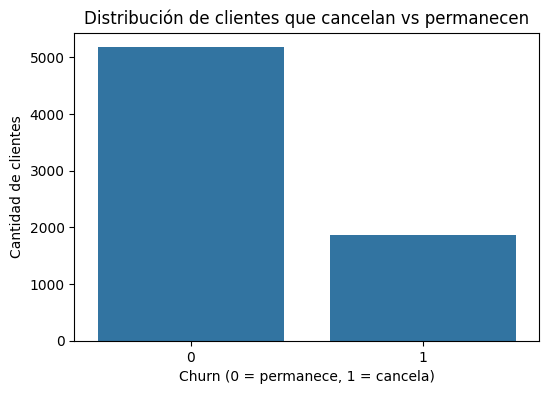

In [42]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Churn')

plt.title('Distribución de clientes que cancelan vs permanecen')
plt.xlabel('Churn (0 = permanece, 1 = cancela)')
plt.ylabel('Cantidad de clientes')

plt.show()

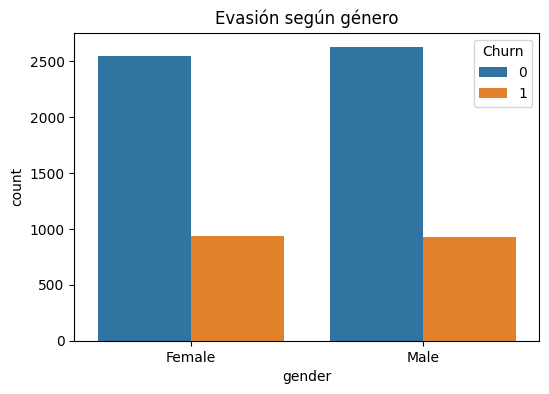

In [43]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='gender', hue='Churn')

plt.title('Evasión según género')

plt.show()

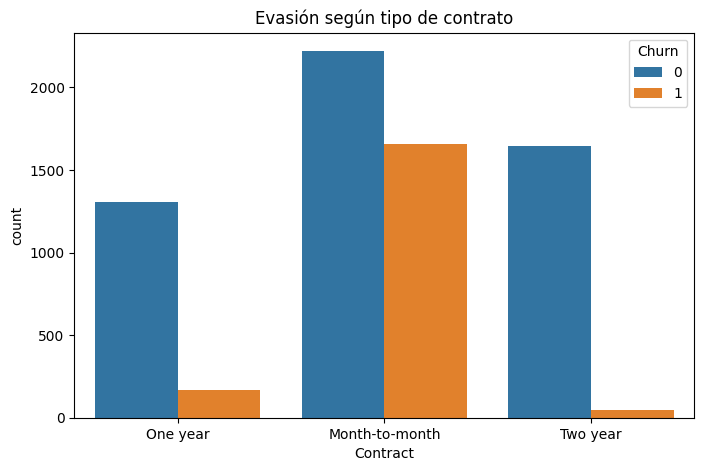

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Contract', hue='Churn')

plt.title('Evasión según tipo de contrato')

plt.show()

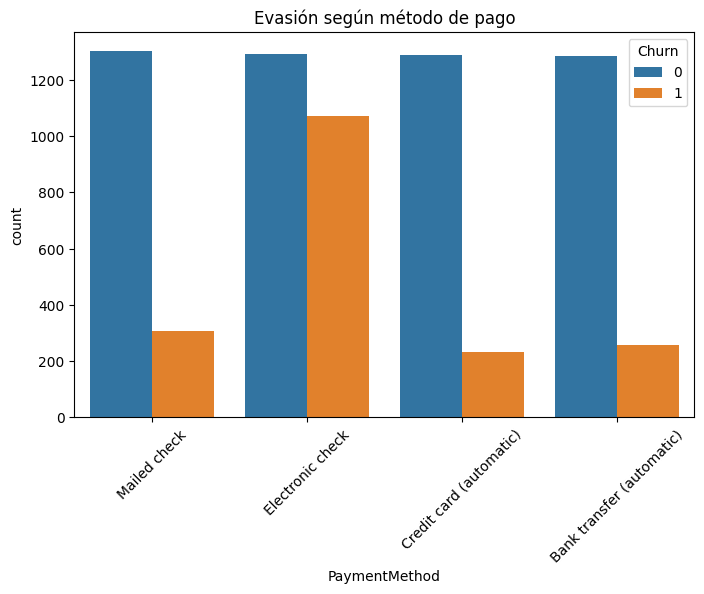

In [45]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='PaymentMethod', hue='Churn')

plt.xticks(rotation=45)

plt.title('Evasión según método de pago')

plt.show()

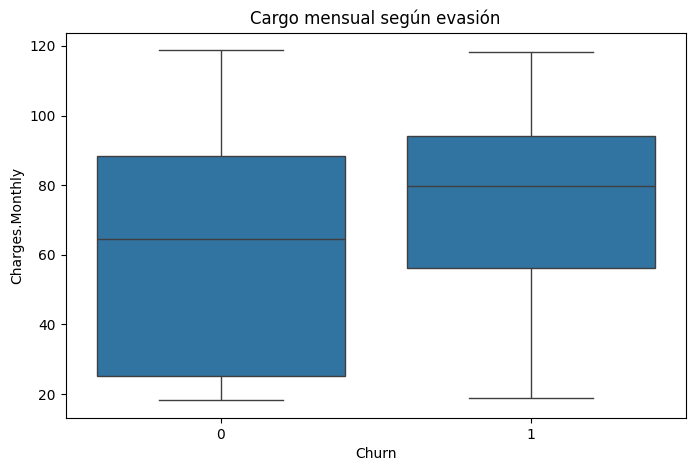

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Churn', y='Charges.Monthly')

plt.title('Cargo mensual según evasión')

plt.show()

In [47]:
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

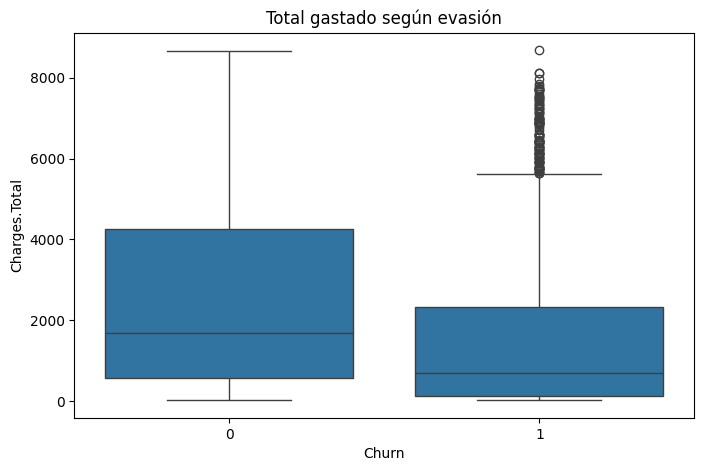

In [48]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Churn', y='Charges.Total')

plt.title('Total gastado según evasión')

plt.show()

##Informe

Introducción

El objetivo de este análisis es estudiar el fenómeno de evasión de clientes (Churn) en la empresa Telecom X. La compañía enfrenta un alto índice de cancelación de servicios y necesita comprender qué factores influyen en este comportamiento para desarrollar estrategias de retención.

Limpieza y tratamiento de datos

Los datos fueron importados desde una API en formato JSON y transformados en un DataFrame utilizando Python y la biblioteca Pandas. Durante el proceso de preparación se realizó la normalización de las estructuras anidadas del JSON para facilitar el análisis.

También se revisaron valores nulos e inconsistencias, se estandarizó la variable Churn y se creó una nueva variable llamada Cuentas_Diarias, calculada a partir del cargo mensual dividido entre 30 días.

Análisis exploratorio

El análisis descriptivo permitió observar la distribución de las variables numéricas del dataset. Posteriormente se analizó la variable Churn para comprender la proporción de clientes que cancelan el servicio.

Se realizaron visualizaciones para analizar la evasión según variables categóricas como el género, el tipo de contrato y el método de pago. También se analizaron variables numéricas como los cargos mensuales y el total gastado por los clientes.

Conclusiones

Los resultados muestran que los clientes con contratos mensuales presentan una mayor tendencia a cancelar el servicio en comparación con aquellos que poseen contratos de mayor duración.

También se observaron diferencias en los cargos mensuales y en el total gastado entre clientes que cancelan y los que permanecen, lo que puede indicar que el costo del servicio influye en la decisión de cancelación.

Recomendaciones

Incentivar contratos de mayor duración para mejorar la retención de clientes.

Analizar la estructura de precios para clientes con cargos mensuales elevados.

Profundizar el análisis de la experiencia del servicio de internet para detectar posibles problemas que generen insatisfacción.